In [1]:
import numpy as np
import pandas as pd

In [13]:
dfs = []

In [14]:


df = pd.read_csv("./hist_data_round_4/prices_round_4_day_1.csv", sep=';', header=0)
dfs.append(df)
# df = pd.read_csv("./hist_data_round_4/prices_round_4_day_2.csv", sep=';', header=0)
# dfs.append(df)
# df = pd.read_csv("./hist_data_round_4/prices_round_4_day_3.csv", sep=';', header=0)
# dfs.append(df)

# df = pd.read_csv("../hist_data_round_2/prices_round_2_day_0.csv", sep=';', header=0)
# dfs.append(df)
# df = pd.read_csv("../hist_data_round_3/prices_round_3_day_1.csv", sep=';', header=0)
# dfs.append(df)
# df = pd.read_csv("../hist_data_round_3/prices_round_3_day_2.csv", sep=';', header=0)
# dfs.append(df)
combined_df = pd.concat(dfs)
combined_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,VOLCANIC_ROCK,10515.0,143.0,10514.0,57.0,NaN,NaN,10517,200,NaN,NaN,NaN,NaN,10516.0,0.0
1,1,0,PICNIC_BASKET1,58705.0,12.0,58704.0,27.0,NaN,NaN,58716,12,58717.0,27.0,NaN,NaN,58710.5,0.0
2,1,0,PICNIC_BASKET2,30252.0,12.0,30251.0,27.0,NaN,NaN,30258,39,NaN,NaN,NaN,NaN,30255.0,0.0
3,1,0,VOLCANIC_ROCK_VOUCHER_9500,1015.0,12.0,NaN,NaN,NaN,NaN,1017,12,NaN,NaN,NaN,NaN,1016.0,0.0
4,1,0,VOLCANIC_ROCK_VOUCHER_9750,766.0,12.0,NaN,NaN,NaN,NaN,767,12,NaN,NaN,NaN,NaN,766.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,1,999900,VOLCANIC_ROCK_VOUCHER_9500,720.0,15.0,NaN,NaN,NaN,NaN,722,15,NaN,NaN,NaN,NaN,721.0,0.0
149996,1,999900,VOLCANIC_ROCK_VOUCHER_10500,8.0,15.0,NaN,NaN,NaN,NaN,9,15,NaN,NaN,NaN,NaN,8.5,0.0
149997,1,999900,VOLCANIC_ROCK_VOUCHER_9750,472.0,15.0,NaN,NaN,NaN,NaN,473,15,NaN,NaN,NaN,NaN,472.5,0.0
149998,1,999900,PICNIC_BASKET1,58713.0,15.0,58712.0,21.0,NaN,NaN,58724,15,58725.0,21.0,NaN,NaN,58718.5,0.0


In [15]:
import matplotlib.pyplot as plt

In [16]:
# Define a function to calculate the weighted mean
def weighted_mean(window):
    weights = np.arange(1, len(window) + 1)  # Assign weights (1, 2, 3, ...)
    return np.dot(window, weights) / weights.sum()

In [29]:
df = pd.read_csv("./hist_data_round_3/prices_round_3_day_2.csv", sep=';', header=0)
croissant = combined_df[["timestamp", "mid_price"]][combined_df['product']== ('CROISSANTS')]
croissant['weightedmean'] = croissant['mid_price'].rolling(150).apply(weighted_mean, raw=False)

In [30]:
croissant.reset_index(inplace=True)

In [ ]:


def mark_peaks_troughs(index, window = 100, sharp = 0.00001):
    # Define the range for left and right neighbors
    left_range = croissant['weightedmean'].iloc[max(0, index - window):index]
    right_range = croissant['weightedmean'].iloc[index + 1:min(len(croissant), index + window +1 - 50)]

    current_price = croissant['weightedmean'].iloc[index]
    # print(current_price)
    # Check for peak
    if current_price >= left_range.max()  and current_price >= right_range.max() and current_price >= left_range.mean() * (1+sharp)\
        and current_price >= right_range.mean() * (1+sharp):

        return 1  # Peak
    # Check for trough
    elif current_price <= left_range.min() and current_price <= right_range.min()\
        and current_price <= left_range.mean() * (1-sharp) and current_price <= right_range.mean() * (1-sharp):

        return 0  # Trough
    return None  # Neither

# Apply rolling window
croissant['peak_trough'] = [mark_peaks_troughs(i) for i in range(len(croissant))]
# croissant['peak_trough'] = replace_with_nan(croissant['peak_trough'])

# mark_peaks_troughs(225)

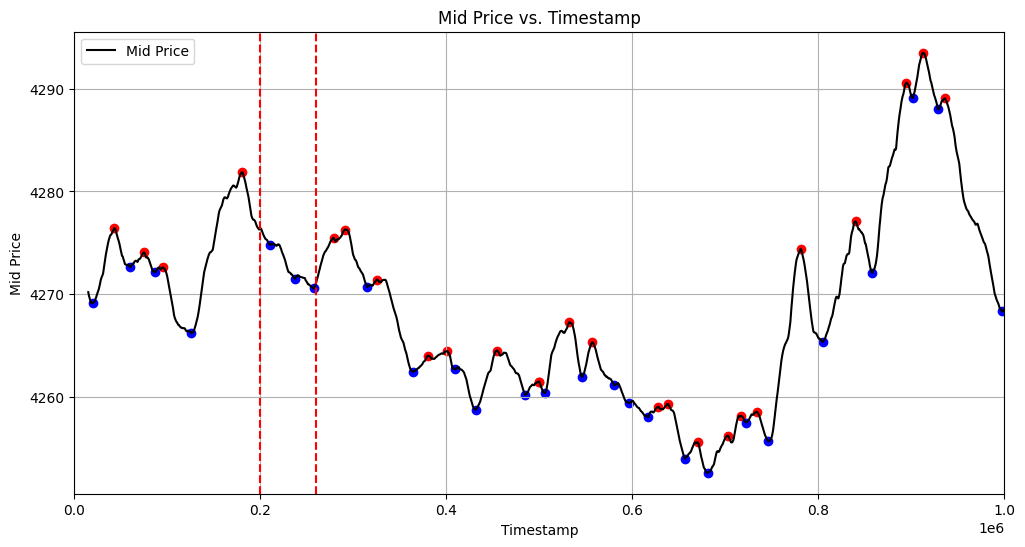

In [ ]:
plt.figure(figsize=(12, 6))
# plt.plot(croissant['timestamp'], croissant['mid_price'], label='Mid Price', color='black')
plt.plot(croissant['timestamp'],croissant['weightedmean'], label='Mid Price', color='black')

# Highlight peaks and troughs
for i in range(len(croissant)):

    if croissant['peak_trough'].iloc[i] == 1:
        plt.scatter(croissant['timestamp'].iloc[i], croissant['weightedmean'].iloc[i], color='red')
    elif croissant['peak_trough'].iloc[i] == 0:
        plt.scatter(croissant['timestamp'].iloc[i], croissant['weightedmean'].iloc[i], color='blue')

# Add labels and title
plt.xlabel('Timestamp')
plt.xlim(00000, 1000000)
# plt.ylim(4260, 4280)
plt.ylabel('Mid Price')
plt.title('Mid Price vs. Timestamp')
plt.axvline(x=200000, color='red', linestyle='--') 
window = 300
plt.axvline(x=200000 + 2*window *100, color='red', linestyle='--') 
plt.legend()
plt.grid()
plt.show()

In [55]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

In [33]:
df = pd.read_csv("./hist_data_round_4/prices_round_4_day_1.csv", sep=';', header=0)


In [34]:
# create new features
def weighted_mean(window):
    weights = np.arange(1, len(window) + 1)  # Assign weights (1, 2, 3, ...)
    return np.dot(window, weights) / weights.sum()

def mark_peaks_troughs(index, window = 100, sharp = 0.00001):
    # Define the range for left and right neighbors
    left_range = df['weighted_avg'].iloc[max(0, index - window):index]
    right_range = df['weighted_avg'].iloc[index + 1:min(len(df), index + window +1 -50)]

    current_price = df['weighted_avg'].iloc[index]
    # print(current_price)
    # Check for peak
    if current_price >= left_range.max()  and current_price >= right_range.max() and current_price >= left_range.mean() * (1+sharp)\
        and current_price >= right_range.mean() * (1+sharp):

        return 1  # Peak
    # Check for trough
    elif current_price <= left_range.min() and current_price <= right_range.min()\
        and current_price <= left_range.mean() * (1-sharp) and current_price <= right_range.mean() * (1-sharp):

        return 0  # Trough
    return None  # Neither

In [35]:
def replace_with_nan(arr):
    """
    Replaces values in a NumPy array with NaN if they are the same as the next valid value.

    Args:
        arr (np.ndarray): The input NumPy array containing 0s, 1s, and NaNs.

    Returns:
        np.ndarray: A new NumPy array with the replacements made.
    """
    arr = np.copy(arr)  # Operate on a copy to avoid modifying the original
    valid_indices = np.where(~np.isnan(arr))[0]  # Indices of valid (non-NaN) values

    if len(valid_indices) < 2:
        return arr  # Nothing to compare if there are fewer than 2 valid values

    for i in range(len(valid_indices) - 1):
        current_index = valid_indices[i]
        next_index = valid_indices[i+1]

        if arr[current_index] == arr[next_index]:
            arr[current_index] = np.nan

    return arr

In [36]:
df = df[df['product']== ('CROISSANTS')]


In [37]:
# transform the input into model input

df['new_bid_volume'] = df['bid_volume_1'].fillna(0) + df['bid_volume_2'].fillna(0) * 0.8
df['new_ask_volume'] = df['ask_volume_1'].fillna(0) + df['ask_volume_2'].fillna(0) * 0.8
df['bidask'] = df['new_bid_volume'] / df ['new_ask_volume']
df['weighted_avg'] = df['mid_price'].rolling(133).apply(weighted_mean, raw=False)
delta = df['mid_price'].diff()
gain = (delta.where(delta >0, 0)).rolling(window=133).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=133).mean()
rs = gain / loss
rsi = 100 - (100 / (1 + rs))
df['RSI'] = rsi.fillna(method='ffill')
df['peak_trough'] = [mark_peaks_troughs(i) for i in range(len(df))]
df['peak_trough'] = replace_with_nan(df['peak_trough'])
df['peak_trough'] = df['peak_trough'].fillna(method='bfill')
short_ema = df['mid_price'].rolling(70).apply(weighted_mean, raw=False)

# Calculate the long-term EMA (26 periods)
long_ema = df['mid_price'].rolling(140).apply(weighted_mean, raw=False)

# Calculate the MACD line
df['MACD'] = short_ema - long_ema

C:\Users\Casen\AppData\Local\Temp\ipykernel_4508\23374240.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['RSI'] = rsi.fillna(method='ffill')
C:\Users\Casen\AppData\Local\Temp\ipykernel_4508\23374240.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['peak_trough'] = df['peak_trough'].fillna(method='bfill')


In [38]:
reduced_df  =df[['timestamp', 'weighted_avg', 'bidask', 'RSI', 'peak_trough', 'MACD']]
reduced_df.reset_index(inplace= True)

In [39]:
trim_df = reduced_df.dropna()

# Find the first valid index after dropping NaNs
# first_valid_index = clean_df.first_valid_index()

# # Find the last valid index after dropping NaNs
# last_valid_index = clean_df.last_valid_index()

# trim_df = reduced_df.iloc[first_valid_index:last_valid_index+1]

In [40]:
window_size = 30
max_windows = len(trim_df) - window_size 
label = trim_df['peak_trough'].copy()
X_windows_3d = np.zeros((max_windows, window_size, 4))
y_labels = np.zeros(max_windows)

for i in range(max_windows):

    features_window = trim_df[['weighted_avg', 'bidask', 'MACD', 'RSI' ]].iloc[i:i + window_size].values

    # Store in our 3D array
    X_windows_3d[i] = features_window

    # Create label: 1 if price goes up, 0 if it goes down or stays the same
    y_labels[i] = label.iloc[i + window_size - 1]  # Last price in window (50th)

print(f"X_windows_3d shape: {X_windows_3d.shape}")
print(f"y_labels shape: {y_labels.shape}")

X_windows_3d shape: (9807, 30, 4)
y_labels shape: (9807,)


In [41]:
mean_vals = X_windows_3d[:, :, :3].mean(axis=1, keepdims=True)  # Mean of channels 0 and 1
std_vals = X_windows_3d[:, :, :3].std(axis=1, keepdims=True)    # Std of channels 0 and 1
epsilon = 1e-10
normalized_price_bidask = (X_windows_3d[:, :, :3] - mean_vals) / (std_vals + epsilon)

# 2. Min-Max Scale RSI (channel 2)
rsi_data = X_windows_3d[:, :, 3]  # Extract RSI data
rsi_scaled = rsi_data /100
rsi_scaled = np.expand_dims(rsi_scaled, axis=2)


# 3. Combine the preprocessed channels
normalised = np.concatenate((normalized_price_bidask, rsi_scaled), axis=2)

In [42]:
rawX = np.expand_dims(normalised, axis=2)
X = rawX
y = y_labels

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
model_h5 = tf.keras.models.load_model('./machine learning/ourmodel.keras')
predictions = model_h5.predict(X)
r_sq = r2_score(y, predictions)
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
r_sq, mae, mse

In [ ]:
croissant = trim_df.copy()
croissant = croissant.reset_index()

In [ ]:
predictions.shape, croissant.shape

In [ ]:
# Add 30 NaNs BEFORE predictions
new_column_with_nan = pd.concat([
    pd.Series([np.nan] * 30),  # NaNs at the start
    pd.Series(predictions.squeeze())      # Predictions after
], ignore_index=True)

print(new_column_with_nan.head(35)) 

In [ ]:
croissant['prediction'] = new_column_with_nan

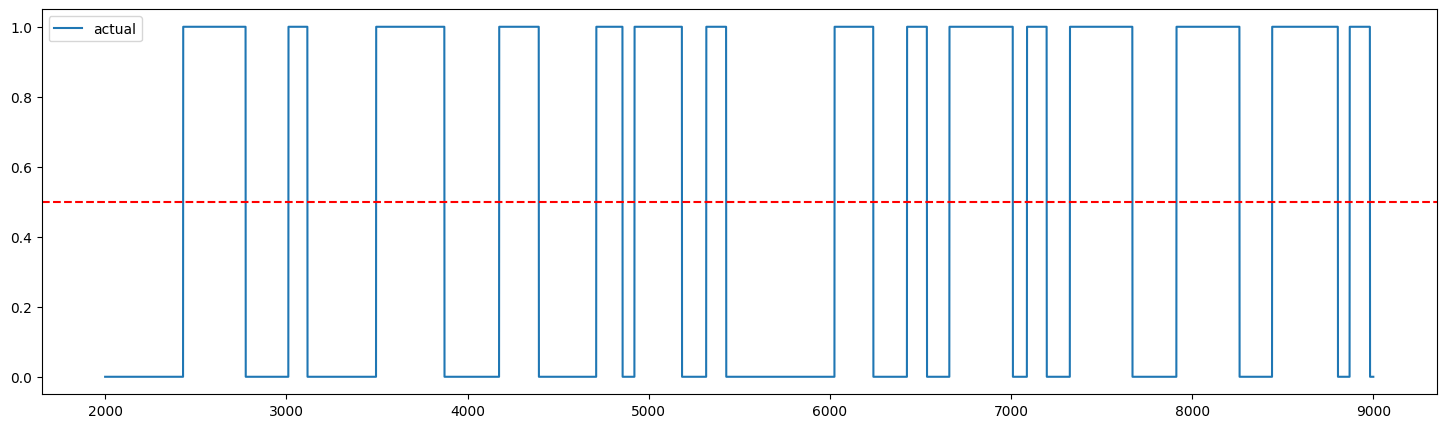

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
# plt.plot(croissant['prediction'].iloc[2000:4000].ewm(span=30, adjust=False).mean())
# plt.plot(croissant['prediction'].iloc[2000:9000].ewm(span=100, adjust=False).mean(), label='predicted')
plt.plot(croissant['peak_trough'].iloc[2000:9000], label='actual')
plt.axhline(0.5, color='red', linestyle='--')
# plt.axhline(0.6, color='green', linestyle='--') 
# plt.axhline(0.4, color='green', linestyle='--') 

plt.legend()

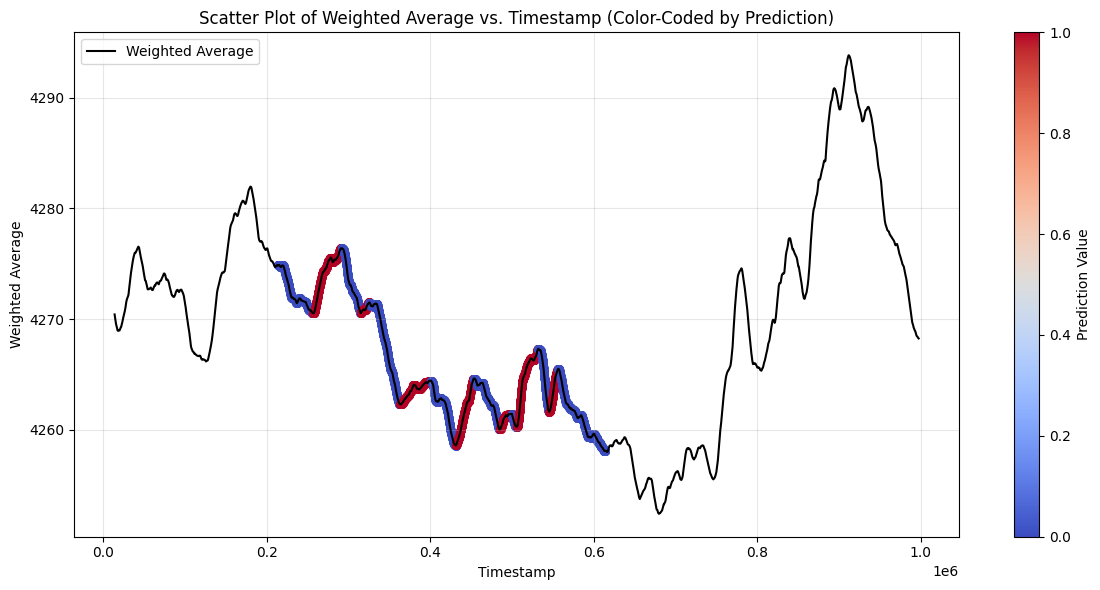

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# First, check if croissant exists
try:
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot the weighted average on the specified axis
    ax.plot(croissant['timestamp'], croissant['weighted_avg'], label='Weighted Average', color='black')
    # ax.plot(croissant['timestamp'], croissant['mid_price'], label='raw price', color='green')
    
    # Define the colormap
    cmap = plt.cm.coolwarm
    
    # Normalize the prediction values to the range [0, 1]
    norm = plt.Normalize(0, 1)  # Assuming predictions are between 0 and 1
    
    # Scatter plot for color-coded predictions
    # Only plot points between indices 2000 and 5000
    plot_range = croissant.iloc[2000:6000]
    
    for i, row in plot_range.iterrows():
        prediction_value = row['prediction']  ###!!!!! change this line if want the display of color change
        color = cmap(norm(prediction_value))  # Get color from colormap
        ax.scatter(row['timestamp'], row['weighted_avg'], color=color, s=30)
    
    # Add a colorbar to show the mapping - explicitly passing the axis
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Necessary for the ScalarMappable
    cbar = fig.colorbar(sm, ax=ax)  # Create the colorbar with explicit reference to ax
    cbar.set_label('Prediction Value')  # Label for colorbar
    
    # Set labels and title
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Weighted Average')
    ax.set_title('Scatter Plot of Weighted Average vs. Timestamp (Color-Coded by Prediction)')
    
    # Use data-driven limits if possible, otherwise use your specified values
    # min_x =  200000
    # max_x =  900000
    # ax.set_xlim(min_x, max_x)
    
    # min_y = 4250
    # max_y =  4350
    # ax.set_ylim(min_y, max_y)
    
    # Optional: Highlight vertical lines
    # window = 100
    # ax.axvline(x=200000, color='red', linestyle='--') 
    # ax.axvline(x=200000 + 2 * window * 100, color='red', linestyle='--')
    
    # Show legend and grid
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Display the plot
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("Error: 'croissant' DataFrame is not defined.")
except KeyError as e:
    print(f"Error: Missing column in DataFrame: {e}")